In [34]:
import pandas as pd

# تجربة القراءة بترميز latin-1 لحل مشكلة الـ Unicode
try:
    df = pd.read_csv('spam.csv', encoding='latin-1')
    print("تمت قراءة الملف بنجاح!")
    print(df.head())
except Exception as e:
    print(f"حدث خطأ: {e}")

تمت قراءة الملف بنجاح!
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


In [35]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# تحميل الملف (تأكد من استخدام الـ encoding الصحيح)
df = pd.read_csv('spam.csv', encoding='latin-1')
# إعادة تسمية الأعمدة لتسهيل العمل (اختياري)
df = df[['v1', 'v2']]
df.columns = ['label', 'text']

# تحميل الموارد المطلوبة
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # تنظيف النص من الرموز والارقام
    text = re.sub(r'[^\w\s]', '', str(text).lower())
    # الـ Tokenization وحذف الـ Stop words مع الـ Lemmatization
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return cleaned_tokens

# تطبيق التنظيف
df['tokens'] = df['text'].apply(preprocess_text)
print("تم الانتهاء من تنظيف النص بنجاح!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\C.S\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\C.S\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


تم الانتهاء من تنظيف النص بنجاح!


In [36]:
from gensim.models import Word2Vec
import numpy as np

# تدريب موديل Word2Vec على الكلمات التي استخرجناها
w2v_model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=1, workers=4)

# دالة لتحويل كل جملة إلى Vector واحد (عن طريق حساب متوسط الـ Vectors لكلماتها)
def get_sentence_vector(tokens):
    vectors = [w2v_model.wv[word] for word in tokens if word in w2v_model.wv]
    if len(vectors) == 0:
        return np.zeros(100)
    return np.mean(vectors, axis=0)

# تحويل كل النصوص إلى أرقام (Vectors)
X = np.array([get_sentence_vector(t) for t in df['tokens']])
y = df['label'].map({'ham': 0, 'spam': 1}) # تحويل الـ labels لأرقام

Overall Accuracy: 95.87%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       0.97      0.71      0.82       150

    accuracy                           0.96      1115
   macro avg       0.96      0.86      0.90      1115
weighted avg       0.96      0.96      0.96      1115



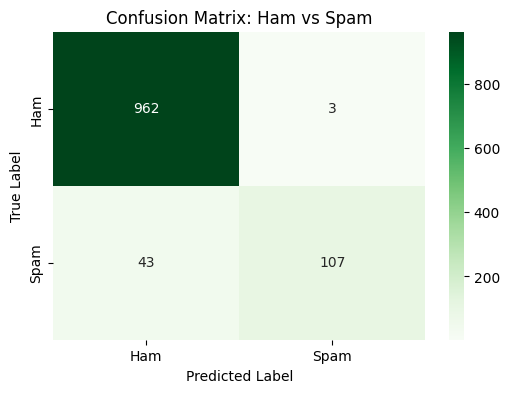

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. بناء الموديل مع موازنة الفئات (Class Weights)
# نستخدم n_estimators=100 (عدد الأشجار) و class_weight='balanced'
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. التدريب (Training)
rf_model.fit(X_train, y_train)

# 3. التوقع (Testing)
y_pred = rf_model.predict(X_test)

# 4. التقييم الشامل
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

# 5. رسم الـ Confusion Matrix لشرح النتائج بصرياً
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Ham vs Spam')
plt.show()

In [38]:
from sklearn.model_selection import train_test_split

# تقسيم البيانات: 80% للتدريب و 20% للاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
from sklearn.ensemble import RandomForestClassifier

# تعديل الموديل ليكون حساساً جداً للـ Spam
# لاحظ الوزن {0: 1, 1: 10} يعني أن خطأ واحد في الـ Spam يعادل 10 أخطاء في الـ Ham
rf_model = RandomForestClassifier(
    n_estimators=200, 
    class_weight={0: 1, 1: 10}, 
    random_state=42
)

# إعادة التدريب
rf_model.fit(X_train, y_train)

print("Model retrained with higher sensitivity to Spam!")

Model retrained with higher sensitivity to Spam!


In [40]:
from sklearn.metrics import accuracy_score, classification_report

# التوقع
y_pred = rf_model.predict(X_test)

# حساب الدقة
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 95.61%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       0.96      0.70      0.81       150

    accuracy                           0.96      1115
   macro avg       0.96      0.85      0.89      1115
weighted avg       0.96      0.96      0.95      1115



In [52]:
def predict_sms(message):
    # 1. تنظيف النص الجديد بنفس الطريقة السابقة
    cleaned_msg = preprocess_text(message) 
    
    # 2. تحويل النص المنظف إلى Vector باستخدام Word2Vec
    # ملاحظة: نستخدم دالة get_sentence_vector التي عرفناها سابقاً
    vector = get_sentence_vector(cleaned_msg).reshape(1, -1)
    
    # 3. التوقع باستخدام الموديل المدرب
    prediction = rf_model.predict(vector)
    
    # 4. النتيجة
    result = "Spam 🚫" if prediction[0] == 1 else "Ham (Safe) ✅"
    return result

# --- جرب الموديل الآن ---
print("Test 1:", predict_sms("you just won a 1000 dollars! give me your bank details to claim"))
#print("Test 2:", predict_sms("Hey, are we still meeting for lunch at 2 PM? Let me know."))

Test 1: Ham (Safe) ✅
